In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
from google.colab import files
files.upload()

Saving KNN_Resume_Job_Matching_Dataset.xlsx to KNN_Resume_Job_Matching_Dataset.xlsx


{'KNN_Resume_Job_Matching_Dataset.xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00\xebz\xd2\x93b\x01\x00\x00\x90\x04\x00\x00\x13\x00\xdc\x01[Content_Types].xml \xa2\xd8\x01(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [3]:
df = pd.read_excel("KNN_Resume_Job_Matching_Dataset.xlsx")
df.head()


,Candidate_ID,Years_of_Experience,Skill_Match_Score,Programming_Skill_Level,Domain_Knowledge_Level,Certifications_Count,Coding_Test_Score,Communication_Score,Job_Role_Code,Job_Fit
0,C0001,8.5,56,4,2,1,81,5,2,Average
1,C0002,7.5,48,2,4,0,55,8,1,Poor
2,C0003,6.7,46,1,3,3,99,5,3,Poor
3,C0004,1.5,77,1,3,1,76,5,2,Average
4,C0005,1.6,44,3,3,1,44,5,1,Poor


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Candidate_ID             200 non-null    object 
 1   Years_of_Experience      200 non-null    float64
 2   Skill_Match_Score        200 non-null    int64  
 3   Programming_Skill_Level  200 non-null    int64  
 4   Domain_Knowledge_Level   200 non-null    int64  
 5   Certifications_Count     200 non-null    int64  
 6   Coding_Test_Score        200 non-null    int64  
 7   Communication_Score      200 non-null    int64  
 8   Job_Role_Code            200 non-null    int64  
 9   Job_Fit                  200 non-null    object 
dtypes: float64(1), int64(7), object(2)
memory usage: 15.8+ KB


In [5]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])


In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
accuracy_list = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracy_list.append(acc)

best_k = accuracy_list.index(max(accuracy_list)) + 1
print("Best K:", best_k)
print("Best Accuracy:", max(accuracy_list))


Best K: 11
Best Accuracy: 0.75


In [12]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=11)

In [13]:
y_pred = model.predict(X_test)


In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Final KNN Accuracy:", accuracy)


Final KNN Accuracy: 0.75


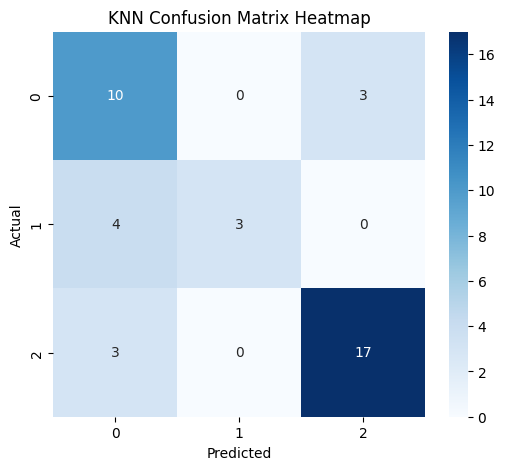

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix Heatmap")
plt.show()


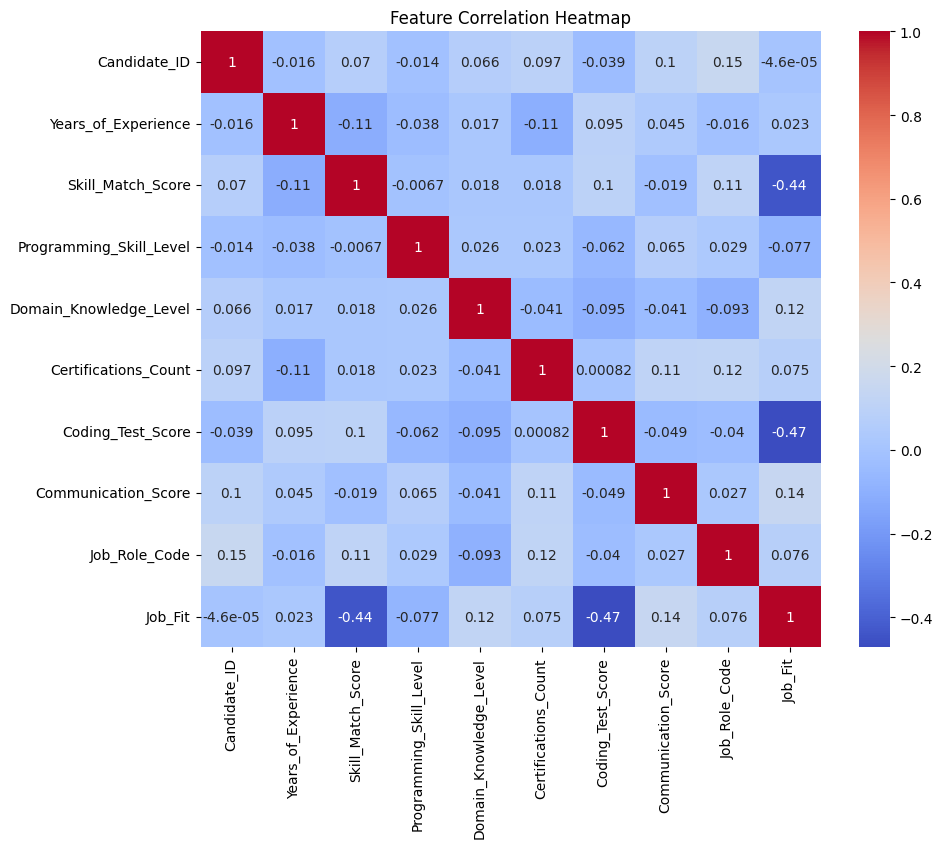

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [19]:
# Example new user (replace with real values for all 9 features)
# Features in order: Candidate_ID, Years_of_Experience, Skill_Match_Score, Programming_Skill_Level, Domain_Knowledge_Level, Certifications_Count, Coding_Test_Score, Communication_Score, Job_Role_Code
# Assuming the user's initial 6 values were: Years_of_Experience (5), Skill_Match_Score (3), Programming_Skill_Level (2), Domain_Knowledge_Level (4), Certifications_Count (1), Coding_Test_Score (6)
# Adding placeholder values for Candidate_ID (200), Communication_Score (5), Job_Role_Code (2)
new_user = np.array([[200, 5, 3, 2, 4, 1, 6, 5, 2]])

# Scale the new user data
new_user_scaled = scaler.transform(new_user)

# Predict numerical label for Job_Fit
prediction = model.predict(new_user_scaled)

# Get the encoded values for each category from the LabelEncoder
# Assuming alphabetical order for LabelEncoder: Average -> 0, Good -> 1, Poor -> 2
encoded_poor = le.transform(['Poor'])[0]
encoded_average = le.transform(['Average'])[0]
encoded_good = le.transform(['Good'])[0]

# Define the custom satisfaction mapping
satisfaction_mapping = {
    encoded_poor: 1,    # Poor Job Fit -> Satisfaction Level 1
    encoded_average: 3, # Average Job Fit -> Satisfaction Level 3
    encoded_good: 5     # Good Job Fit -> Satisfaction Level 5
}

# Apply the mapping to the predicted numerical label
predicted_satisfaction_level = satisfaction_mapping[prediction[0]]

print("Predicted Satisfaction Level (1-5):", predicted_satisfaction_level)

Predicted Satisfaction Level (1-5): 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
